# Assignment 1: Student Performance Prediction Using ANN

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [4]:
from google.colab import files

uploaded = files.upload()
DATA_PATH = next(iter(uploaded))

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Saving student_performance_prediction_dataset-2.csv to student_performance_prediction_dataset-2 (1).csv
Dataset shape: (300000, 25)


,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [5]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["final_grade"].describe())


Shape: (300000, 25)

Data types:


,dtype
student_id,int64
age,int64
gender,object
study_hours,float64
attendance,float64
sleep_hours,float64
previous_grade,float64
assignments_completed,float64
practice_tests_taken,float64
group_study_hours,float64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,300000.0,NaN,NaN,NaN,150000.5,86602.684716,1.0,75000.75,150000.5,225000.25,300000.0
age,300000.0,NaN,NaN,NaN,17.99907,1.999235,15.0,16.0,18.0,20.0,21.0
gender,300000,3,Female,144083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours,300000.0,NaN,NaN,NaN,4.503062,1.978513,0.0,3.143566,4.498272,5.843646,12.0
attendance,300000.0,NaN,NaN,NaN,84.699395,9.41945,40.0,78.241008,84.990371,91.732244,100.0
sleep_hours,300000.0,NaN,NaN,NaN,6.991431,1.46307,3.0,5.992666,6.999011,8.013284,10.0
previous_grade,300000.0,NaN,NaN,NaN,69.840184,14.683157,20.0,59.870863,69.955736,80.102857,100.0
assignments_completed,300000.0,NaN,NaN,NaN,7.836044,1.732474,0.0,6.654817,8.000829,9.357154,10.0
practice_tests_taken,300000.0,NaN,NaN,NaN,4.017508,1.956444,0.0,2.655243,4.001981,5.349494,10.0
group_study_hours,300000.0,NaN,NaN,NaN,1.529057,0.941525,0.0,0.826462,1.499206,2.17268,5.840593



Missing values:


,missing_count
extracurriculars,49981
device_type,15105
grade_category,4



Duplicate rows: 0

Target distribution:


,final_grade
count,300000.000000
mean,53.089206
std,12.225161
min,0.000000
25%,44.867737
50%,53.167495
75%,61.379373
max,100.000000


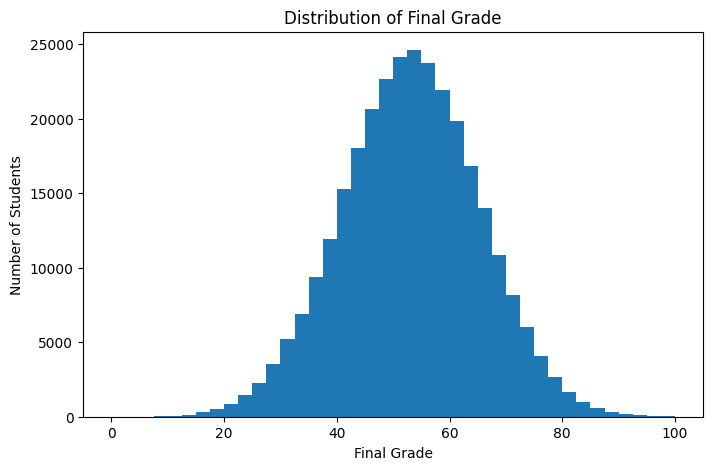

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["final_grade"], bins=40)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grade")
plt.show()


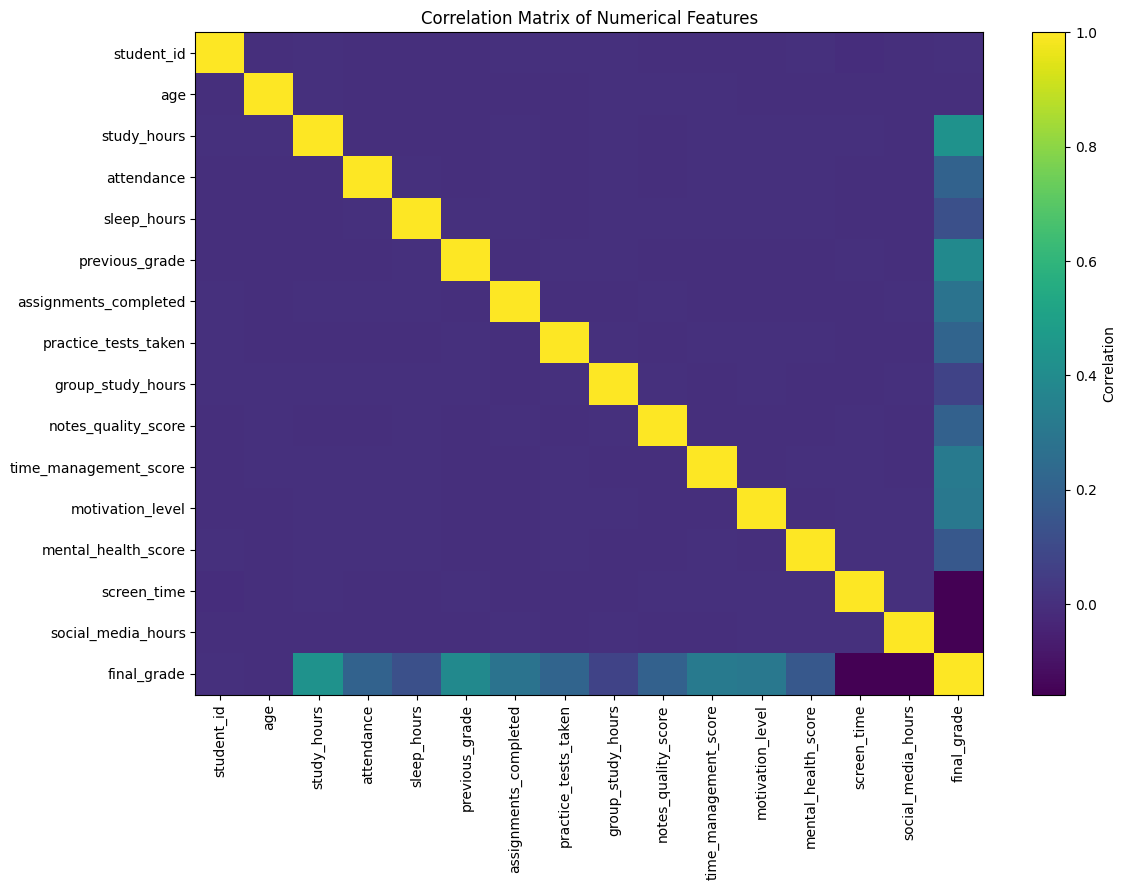

,Correlation with final_grade
study_hours,0.4310
previous_grade,0.3934
time_management_score,0.3128
motivation_level,0.3064
assignments_completed,0.2821
practice_tests_taken,0.2131
attendance,0.2047
notes_quality_score,0.2015
mental_health_score,0.1593
screen_time,-0.1580


In [7]:
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

target_corr = (
    corr_matrix["final_grade"]
    .drop("final_grade")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(target_corr.to_frame("Correlation with final_grade").round(4))


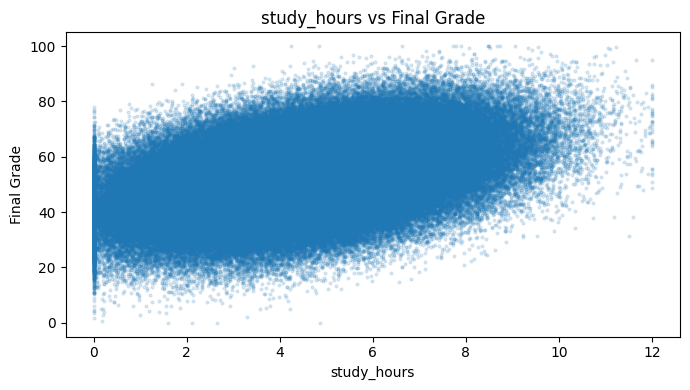

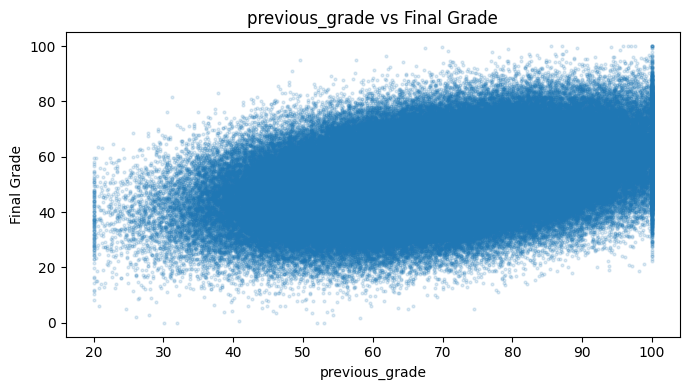

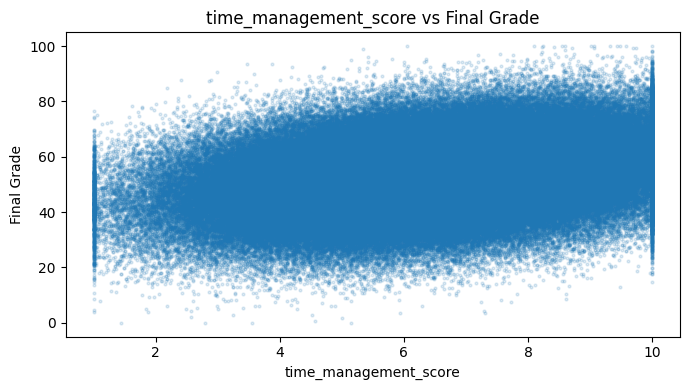

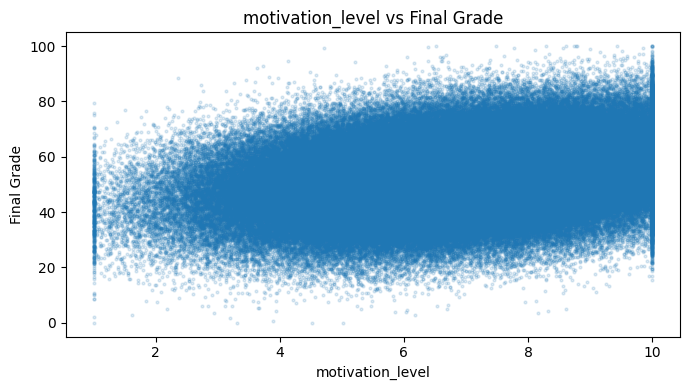

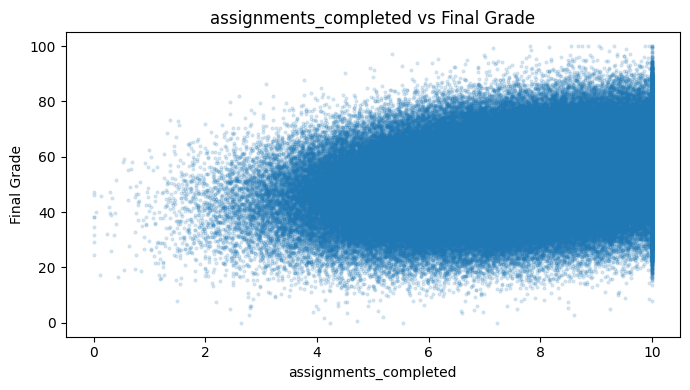

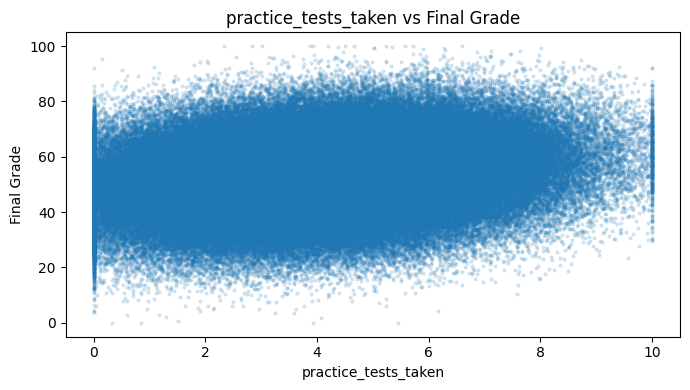

In [8]:
top_features = target_corr.head(6).index.tolist()

for feature in top_features:
    plt.figure(figsize=(7, 4))
    plt.scatter(df[feature], df["final_grade"], s=4, alpha=0.15)
    plt.xlabel(feature)
    plt.ylabel("Final Grade")
    plt.title(f"{feature} vs Final Grade")
    plt.tight_layout()
    plt.show()


In [9]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
categorical_for_eda = [c for c in categorical_cols if c not in ["grade_category", "pass_fail"]]

for col in categorical_for_eda:
    summary = (
        df.groupby(col, dropna=False)["final_grade"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )
    print(f"\n{col}")
    display(summary.round(2))



gender


,mean,count
gender,,
Male,53.09,143871
Female,53.09,144083
Other,53.08,12046



family_income


,mean,count
family_income,,
High,53.12,60074
Low,53.11,105067
Medium,53.06,134859



parent_education


...

,mean,count
device_type,,
Laptop,53.11,164893
Mobile,53.09,90116
Tablet,53.03,29886
NaN,53.00,15105



school_type


,mean,count
school_type,,
Public,53.10,195174
Private,53.08,104826



extracurriculars


,mean,count
extracurriculars,,
Music,53.20,50097
NaN,53.13,49981
Coding Club,53.10,50187
Arts,53.08,50235
Debate,53.06,49703
Sports,52.96,49797


In [10]:
TARGET = "final_grade"

DROP_COLUMNS = [
    "student_id",
    "grade_category",  # target leakage
    "pass_fail"        # target leakage
]

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET].astype("float32")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nInput columns:")
print(list(X.columns))


X shape: (300000, 21)
y shape: (300000,)

Input columns:
['age', 'gender', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars']


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)


Training: (210000, 21)
Validation: (45000, 21)
Testing: (45000, 21)


In [12]:
numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_p = preprocessor.fit_transform(X_train).astype("float32")
X_val_p = preprocessor.transform(X_val).astype("float32")
X_test_p = preprocessor.transform(X_test).astype("float32")

print("Processed training shape:", X_train_p.shape)
print("Processed validation shape:", X_val_p.shape)
print("Processed testing shape:", X_test_p.shape)


Numerical features: ['age', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours']
Categorical features: ['gender', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars']
Processed training shape: (210000, 36)
Processed validation shape: (45000, 36)
Processed testing shape: (45000, 36)


In [13]:
def build_ann(input_dim, activation="relu", hidden_units=(128, 64), optimizer_name="adam"):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden_units[0], activation=activation),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(hidden_units[1], activation=activation),
        tf.keras.layers.Dropout(0.10),
        tf.keras.layers.Dense(1, activation="linear")
    ])

    optimizers = {
        "adam": tf.keras.optimizers.Adam(learning_rate=0.001),
        "sgd": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        "rmsprop": tf.keras.optimizers.RMSprop(learning_rate=0.001)
    }

    model.compile(
        optimizer=optimizers[optimizer_name],
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model


def evaluate_model(model, X_eval, y_eval):
    pred = model.predict(X_eval, verbose=0).ravel()
    return {
        "MAE": mean_absolute_error(y_eval, pred),
        "RMSE": np.sqrt(mean_squared_error(y_eval, pred)),
        "R2": r2_score(y_eval, pred)
    }


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)


In [14]:
activations = ["relu", "tanh", "sigmoid"]
optimizers = ["adam", "sgd", "rmsprop"]

results = []
histories = {}
models = {}

for activation in activations:
    for optimizer in optimizers:
        print(f"\nTraining: {activation.upper()} + {optimizer.upper()}")

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        model = build_ann(
            input_dim=X_train_p.shape[1],
            activation=activation,
            hidden_units=(128, 64),
            optimizer_name=optimizer
        )

        history = model.fit(
            X_train_p, y_train,
            validation_data=(X_val_p, y_val),
            epochs=50,
            batch_size=1024,
            callbacks=[early_stop],
            verbose=0
        )

        metrics = evaluate_model(model, X_val_p, y_val)

        results.append({
            "Model": f"{activation.upper()} + {optimizer.upper()}",
            "Activation": activation,
            "Optimizer": optimizer,
            "Architecture": "128-64",
            "Epochs": len(history.history["loss"]),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"]
        })

        histories[f"{activation}_{optimizer}"] = history
        models[f"{activation}_{optimizer}"] = model

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)



Training: RELU + ADAM

Training: RELU + SGD

Training: RELU + RMSPROP

Training: TANH + ADAM

Training: TANH + SGD

Training: TANH + RMSPROP

Training: SIGMOID + ADAM

Training: SIGMOID + SGD

Training: SIGMOID + RMSPROP


,Model,Activation,Optimizer,Architecture,Epochs,MAE,RMSE,R2
0,RELU + ADAM,relu,adam,128-64,31,3.998457,5.009242,0.828943
2,RELU + RMSPROP,relu,rmsprop,128-64,8,4.266731,5.339417,0.805650
1,RELU + SGD,relu,sgd,128-64,8,8.179719,10.328653,0.272751
7,SIGMOID + SGD,sigmoid,sgd,128-64,8,9.732010,12.174878,-0.010474
4,TANH + SGD,tanh,sgd,128-64,8,9.798841,12.253776,-0.023613
5,TANH + RMSPROP,tanh,rmsprop,128-64,8,28.700813,31.081571,-5.585696
3,TANH + ADAM,tanh,adam,128-64,8,28.980055,31.341037,-5.696109
8,SIGMOID + RMSPROP,sigmoid,rmsprop,128-64,8,39.658058,41.462294,-10.719321
6,SIGMOID + ADAM,sigmoid,adam,128-64,8,40.554890,42.320028,-11.209213


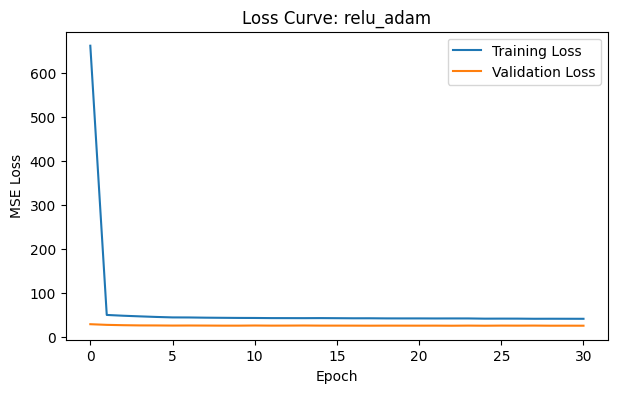

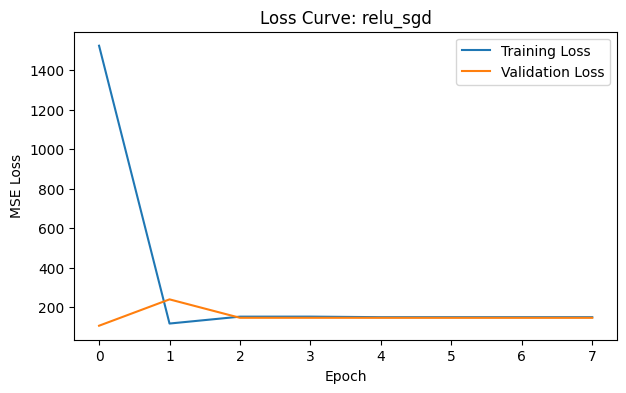

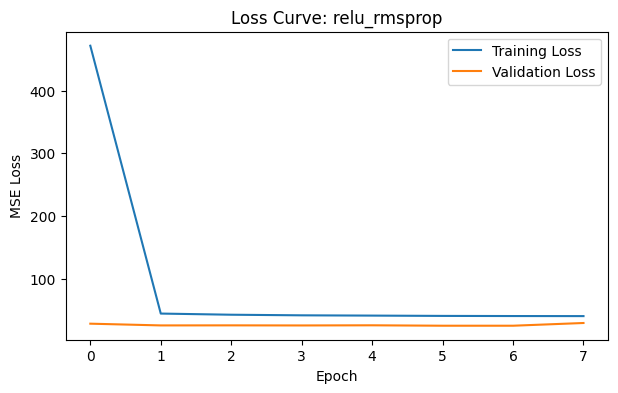

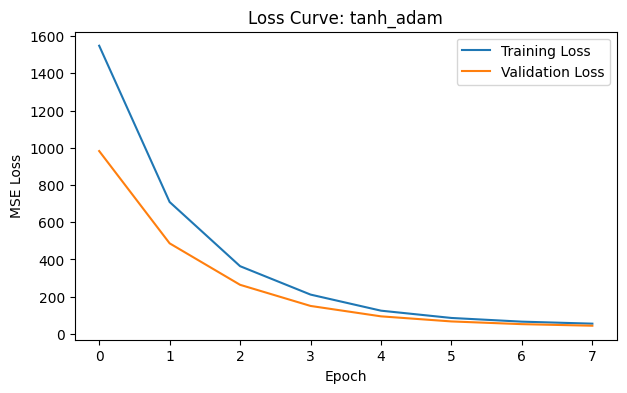

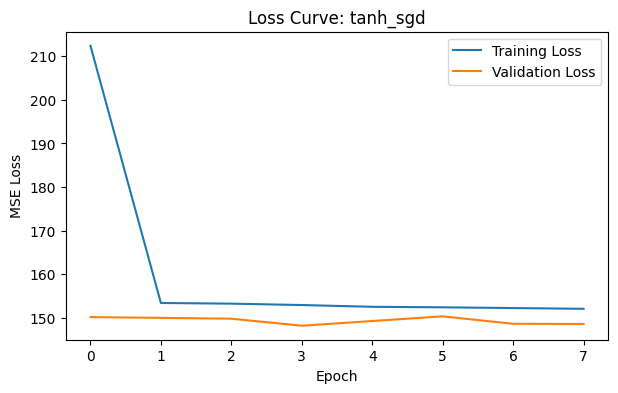

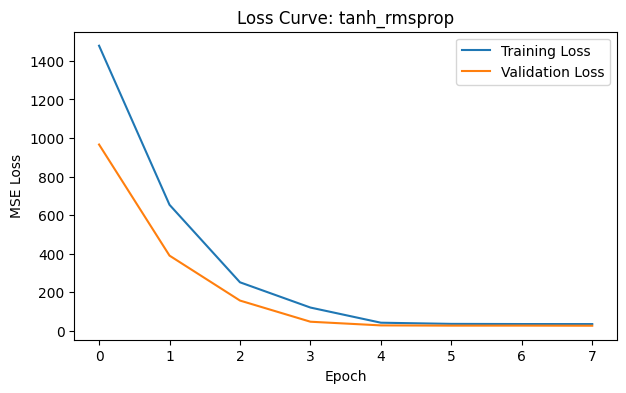

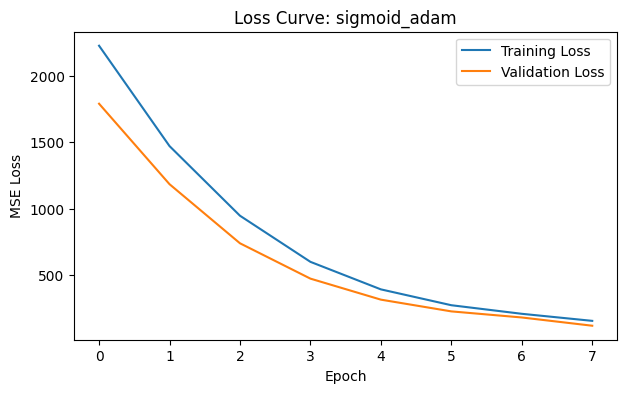

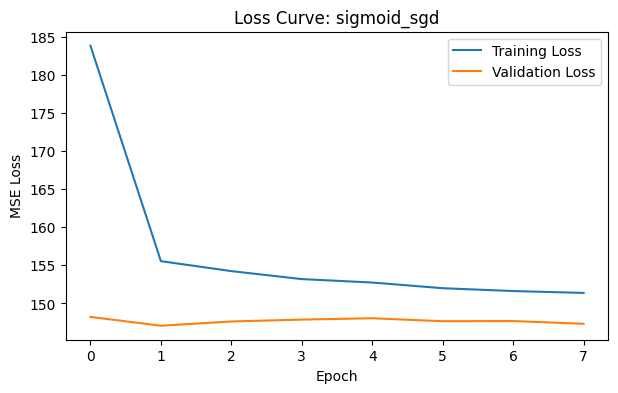

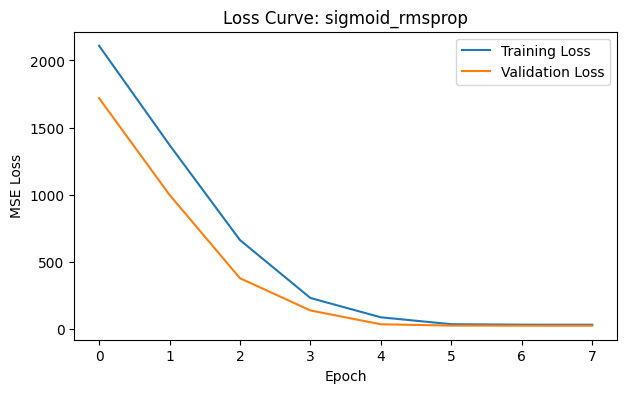

In [15]:
for name, history in histories.items():
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Loss Curve: {name}")
    plt.legend()
    plt.show()


In [16]:
best_row = results_df.iloc[0]
best_activation = best_row["Activation"]
best_optimizer = best_row["Optimizer"]

architectures = {
    "64": (64,),
    "128-64": (128, 64),
    "256-128-64": (256, 128, 64)
}

def build_variable_ann(input_dim, activation, hidden_units, optimizer_name):
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=(input_dim,))])

    for i, units in enumerate(hidden_units):
        model.add(tf.keras.layers.Dense(units, activation=activation))
        if i < len(hidden_units) - 1:
            model.add(tf.keras.layers.Dropout(0.15))

    model.add(tf.keras.layers.Dense(1, activation="linear"))

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model

architecture_results = []
architecture_histories = {}
architecture_models = {}

for name, units in architectures.items():
    print(f"Training architecture: {name}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_variable_ann(
        X_train_p.shape[1],
        best_activation,
        units,
        best_optimizer
    )

    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=50,
        batch_size=1024,
        callbacks=[early_stop],
        verbose=0
    )

    m = evaluate_model(model, X_val_p, y_val)

    architecture_results.append({
        "Architecture": name,
        "Activation": best_activation,
        "Optimizer": best_optimizer,
        "Epochs": len(history.history["loss"]),
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "R2": m["R2"]
    })

    architecture_histories[name] = history
    architecture_models[name] = model

architecture_df = pd.DataFrame(architecture_results).sort_values("RMSE")
display(architecture_df)


Training architecture: 64
Training architecture: 128-64
Training architecture: 256-128-64


,Architecture,Activation,Optimizer,Epochs,MAE,RMSE,R2
0,64,relu,adam,32,3.993102,5.003155,0.829359
1,128-64,relu,adam,8,4.283425,5.372084,0.803265
2,256-128-64,relu,adam,8,4.443085,5.565588,0.788837


In [30]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=architecture_df)

https://docs.google.com/spreadsheets/d/1KhKgcGZCyejostEXYZR8IwOI_H_8fxi1hjdtP9Dy29Q/edit#gid=0


In [17]:
best_architecture_name = architecture_df.iloc[0]["Architecture"]
best_units = architectures[best_architecture_name]

epoch_results = []
epoch_models = {}
epoch_histories = {}

for epochs in [20, 50, 100]:
    print(f"Training for maximum {epochs} epochs")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_variable_ann(
        X_train_p.shape[1],
        best_activation,
        best_units,
        best_optimizer
    )

    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=epochs,
        batch_size=1024,
        callbacks=[early_stop],
        verbose=0
    )

    m = evaluate_model(model, X_val_p, y_val)

    epoch_results.append({
        "Epoch Setting": epochs,
        "Actual Epochs Trained": len(history.history["loss"]),
        "Activation": best_activation,
        "Optimizer": best_optimizer,
        "Architecture": best_architecture_name,
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "R2": m["R2"]
    })

    epoch_models[epochs] = model
    epoch_histories[epochs] = history

epoch_df = pd.DataFrame(epoch_results).sort_values("RMSE")
display(epoch_df)


Training for maximum 20 epochs
Training for maximum 50 epochs
Training for maximum 100 epochs


,Epoch Setting,Actual Epochs Trained,Activation,Optimizer,Architecture,MAE,RMSE,R2
1,50,15,relu,adam,64,3.990634,5.001142,0.829496
0,20,20,relu,adam,64,3.991365,5.001689,0.829459
2,100,8,relu,adam,64,24.947992,25.881422,-3.566380


Best model:


,Value
Epoch Setting,50
Actual Epochs Trained,15
Activation,relu
Optimizer,adam
Architecture,64
MAE,3.990634
RMSE,5.001142
R2,0.829496


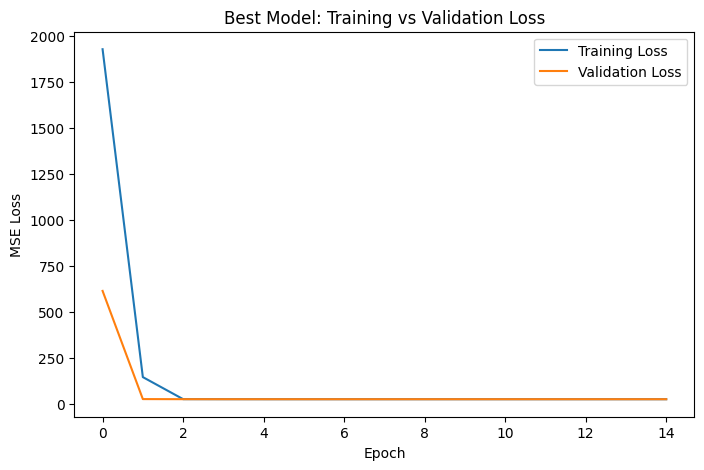

In [18]:
best_epoch_row = epoch_df.iloc[0]
best_epochs = int(best_epoch_row["Epoch Setting"])

best_model = epoch_models[best_epochs]

print("Best model:")
display(best_epoch_row.to_frame("Value"))

# Plot its learning curve
history = epoch_histories[best_epochs]

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Best Model: Training vs Validation Loss")
plt.legend()
plt.show()


In [19]:
test_metrics = evaluate_model(best_model, X_test_p, y_test)

print("Final Test Performance")
print(f"MAE  : {test_metrics['MAE']:.4f}")
print(f"RMSE : {test_metrics['RMSE']:.4f}")
print(f"R²   : {test_metrics['R2']:.4f}")


Final Test Performance
MAE  : 3.9963
RMSE : 5.0075
R²   : 0.8332


In [20]:
predictions = best_model.predict(X_test_p, verbose=0).ravel()

comparison = pd.DataFrame({
    "Actual Final Grade": y_test.to_numpy(),
    "Predicted Final Grade": predictions
})

comparison["Absolute Error"] = (
    comparison["Actual Final Grade"] - comparison["Predicted Final Grade"]
).abs()

display(comparison.head(20).round(2))


,Actual Final Grade,Predicted Final Grade,Absolute Error
0,39.029999,42.799999,3.77
1,36.919998,40.830002,3.91
2,46.810001,54.220001,7.41
3,50.820000,53.220001,2.40
4,36.750000,40.799999,4.05
5,55.570000,47.560001,8.01
6,49.259998,46.700001,2.57
7,55.070000,62.900002,7.82
8,43.910000,44.779999,0.87
9,53.810001,51.250000,2.56


In [21]:
main_comparison = results_df[
    ["Model", "Activation", "Optimizer", "Architecture", "Epochs", "MAE", "RMSE", "R2"]
].copy()

display(main_comparison.round(4))

print("\nBest activation/optimizer combination:")
display(main_comparison.iloc[[0]].round(4))


,Model,Activation,Optimizer,Architecture,Epochs,MAE,RMSE,R2
0,RELU + ADAM,relu,adam,128-64,31,3.9985,5.0092,0.8289
2,RELU + RMSPROP,relu,rmsprop,128-64,8,4.2667,5.3394,0.8057
1,RELU + SGD,relu,sgd,128-64,8,8.1797,10.3287,0.2728
7,SIGMOID + SGD,sigmoid,sgd,128-64,8,9.7320,12.1749,-0.0105
4,TANH + SGD,tanh,sgd,128-64,8,9.7988,12.2538,-0.0236
5,TANH + RMSPROP,tanh,rmsprop,128-64,8,28.7008,31.0816,-5.5857
3,TANH + ADAM,tanh,adam,128-64,8,28.9801,31.3410,-5.6961
8,SIGMOID + RMSPROP,sigmoid,rmsprop,128-64,8,39.6581,41.4623,-10.7193
6,SIGMOID + ADAM,sigmoid,adam,128-64,8,40.5549,42.3200,-11.2092



Best activation/optimizer combination:


,Model,Activation,Optimizer,Architecture,Epochs,MAE,RMSE,R2
0,RELU + ADAM,relu,adam,128-64,31,3.9985,5.0092,0.8289


In [22]:
best_model.save("best_student_performance_ann.keras")

# Optional: save predictions and experiment results
comparison.to_csv("final_predictions.csv", index=False)
main_comparison.to_csv("ann_activation_optimizer_results.csv", index=False)
architecture_df.to_csv("ann_architecture_results.csv", index=False)
epoch_df.to_csv("ann_epoch_results.csv", index=False)

print("Files saved successfully.")


Files saved successfully.


In [23]:
all_experiments = []

# Activation + optimizer experiments
for _, r in results_df.iterrows():
    all_experiments.append({
        "Experiment": "Activation + Optimizer",
        "Model": r["Model"],
        "Activation": r["Activation"].upper(),
        "Optimizer": r["Optimizer"].upper(),
        "Architecture": r["Architecture"],
        "Epochs": int(r["Epochs"]),
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "R2": r["R2"]
    })

# Architecture experiments
for _, r in architecture_df.iterrows():
    all_experiments.append({
        "Experiment": "Architecture",
        "Model": f"{r['Activation'].upper()} + {r['Optimizer'].upper()} / {r['Architecture']}",
        "Activation": r["Activation"].upper(),
        "Optimizer": r["Optimizer"].upper(),
        "Architecture": r["Architecture"],
        "Epochs": int(r["Epochs"]),
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "R2": r["R2"]
    })

# Epoch experiments
for _, r in epoch_df.iterrows():
    all_experiments.append({
        "Experiment": "Epochs",
        "Model": f"{r['Activation'].upper()} + {r['Optimizer'].upper()} / {r['Architecture']} / {int(r['Epoch Setting'])} max epochs",
        "Activation": r["Activation"].upper(),
        "Optimizer": r["Optimizer"].upper(),
        "Architecture": r["Architecture"],
        "Epochs": int(r["Epoch Setting"]),
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "R2": r["R2"]
    })

all_experiments_df = pd.DataFrame(all_experiments).sort_values("RMSE").reset_index(drop=True)
display(all_experiments_df.round(4))


,Experiment,Model,Activation,Optimizer,Architecture,Epochs,MAE,RMSE,R2
0,Epochs,RELU + ADAM / 64 / 50 max epochs,RELU,ADAM,64,50,3.9906,5.0011,0.8295
1,Epochs,RELU + ADAM / 64 / 20 max epochs,RELU,ADAM,64,20,3.9914,5.0017,0.8295
2,Architecture,RELU + ADAM / 64,RELU,ADAM,64,32,3.9931,5.0032,0.8294
3,Activation + Optimizer,RELU + ADAM,RELU,ADAM,128-64,31,3.9985,5.0092,0.8289
4,Activation + Optimizer,RELU + RMSPROP,RELU,RMSPROP,128-64,8,4.2667,5.3394,0.8057
5,Architecture,RELU + ADAM / 128-64,RELU,ADAM,128-64,8,4.2834,5.3721,0.8033
6,Architecture,RELU + ADAM / 256-128-64,RELU,ADAM,256-128-64,8,4.4431,5.5656,0.7888
7,Activation + Optimizer,RELU + SGD,RELU,SGD,128-64,8,8.1797,10.3287,0.2728
8,Activation + Optimizer,SIGMOID + SGD,SIGMOID,SGD,128-64,8,9.7320,12.1749,-0.0105
9,Activation + Optimizer,TANH + SGD,TANH,SGD,128-64,8,9.7988,12.2538,-0.0236


In [24]:
best_activation_row = results_df.iloc[0]
best_architecture_row = architecture_df.iloc[0]
best_epoch_row = epoch_df.iloc[0]

print("BEST MODEL SELECTION")
print("=" * 70)
print(
    f"Best activation/optimizer combination: "
    f"{best_activation_row['Activation'].upper()} + {best_activation_row['Optimizer'].upper()}"
)
print(f"Best architecture: {best_architecture_row['Architecture']}")
print(f"Best epoch setting: {int(best_epoch_row['Epoch Setting'])}")
print(f"Validation MAE: {best_epoch_row['MAE']:.4f}")
print(f"Validation RMSE: {best_epoch_row['RMSE']:.4f}")
print(f"Validation R²: {best_epoch_row['R2']:.4f}")
print()
print("Reason: this configuration achieved the lowest validation RMSE among the")
print("tested configurations, while MAE and R² provide supporting evidence.")


BEST MODEL SELECTION
Best activation/optimizer combination: RELU + ADAM
Best architecture: 64
Best epoch setting: 50
Validation MAE: 3.9906
Validation RMSE: 5.0011
Validation R²: 0.8295

Reason: this configuration achieved the lowest validation RMSE among the
tested configurations, while MAE and R² provide supporting evidence.


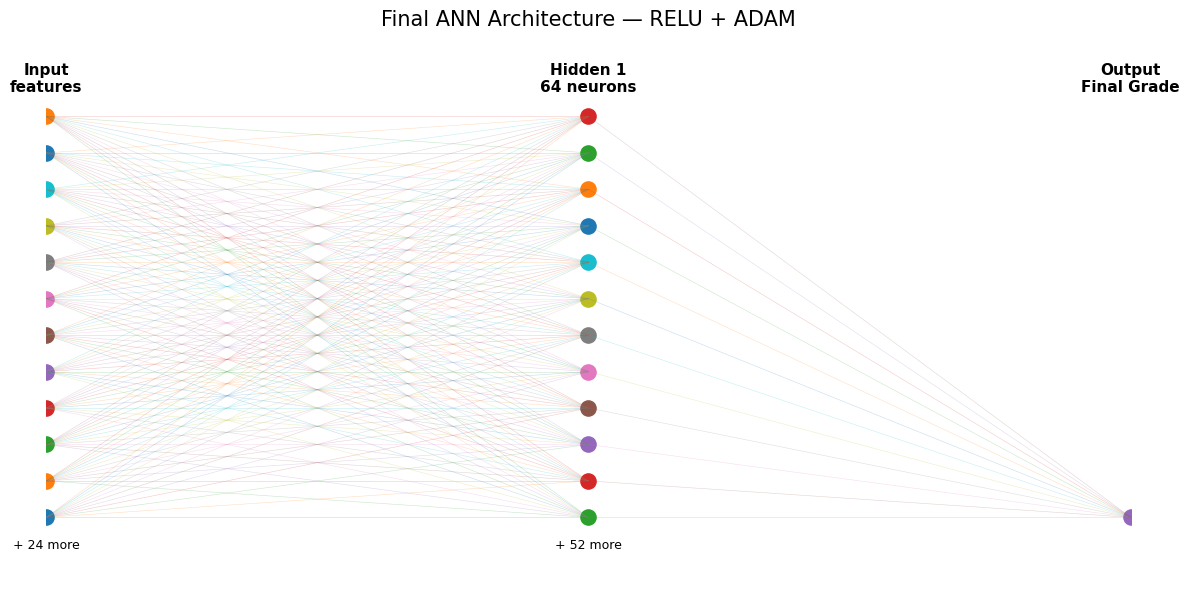

Input dimension: 36
Hidden layers: (64,)
Output: 1 neuron (linear activation) for Final Grade regression


In [25]:
layer_sizes = [X_train_p.shape[1]] + list(best_units) + [1]
layer_labels = (
    ["Input\nfeatures"] +
    [f"Hidden {i+1}\n{n} neurons" for i, n in enumerate(best_units)] +
    ["Output\nFinal Grade"]
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, len(layer_sizes) - 1)
ax.set_ylim(0, max(layer_sizes) + 20)
ax.axis("off")

for layer_idx, size in enumerate(layer_sizes):
    display_n = min(size, 12)
    ys = np.linspace(10, max(layer_sizes) + 10, display_n)

    for y_pos in ys:
        ax.scatter(layer_idx, y_pos, s=120)

    if size > display_n:
        ax.text(layer_idx, 5, f"+ {size-display_n} more", ha="center", fontsize=9)

    ax.text(layer_idx, max(layer_sizes) + 16, layer_labels[layer_idx],
            ha="center", va="center", fontsize=11, fontweight="bold")

for layer_idx in range(len(layer_sizes) - 1):
    left_n = min(layer_sizes[layer_idx], 12)
    right_n = min(layer_sizes[layer_idx + 1], 12)
    left_ys = np.linspace(10, max(layer_sizes) + 10, left_n)
    right_ys = np.linspace(10, max(layer_sizes) + 10, right_n)

    for y1 in left_ys:
        for y2 in right_ys:
            ax.plot([layer_idx, layer_idx + 1], [y1, y2], linewidth=0.4, alpha=0.25)

ax.set_title(
    f"Final ANN Architecture — {best_activation.upper()} + {best_optimizer.upper()}",
    fontsize=15,
    pad=20
)
plt.tight_layout()
plt.show()

print("Input dimension:", X_train_p.shape[1])
print("Hidden layers:", best_units)
print("Output: 1 neuron (linear activation) for Final Grade regression")


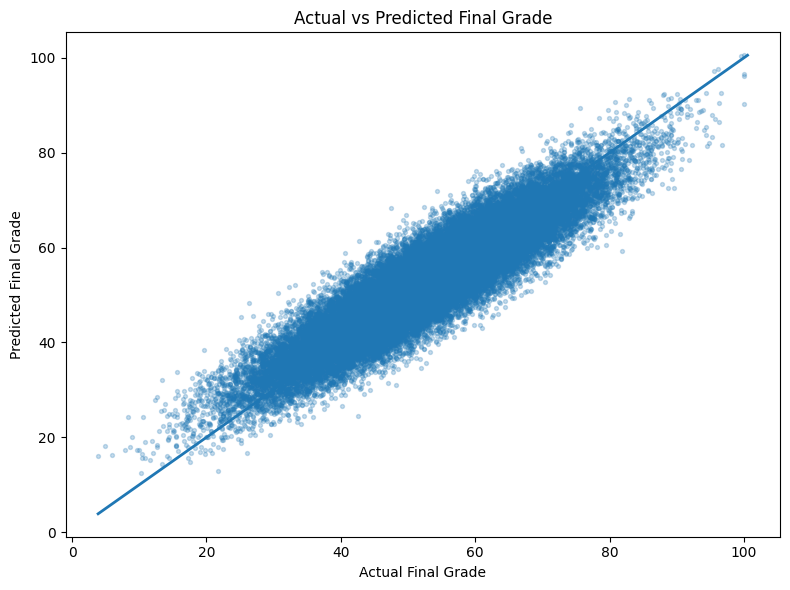

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, s=8, alpha=0.25)

min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())

plt.plot([min_value, max_value], [min_value, max_value], linewidth=2)
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grade")
plt.tight_layout()
plt.show()


In [27]:
train_loss = np.array(history.history["loss"])
val_loss = np.array(history.history["val_loss"])

best_val_idx = int(np.argmin(val_loss))
best_val_loss = val_loss[best_val_idx]
train_loss_at_best = train_loss[best_val_idx]
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

gap_at_best = best_val_loss - train_loss_at_best
relative_gap = gap_at_best / max(abs(best_val_loss), 1e-8)

print(f"Best validation loss: {best_val_loss:.4f} (epoch {best_val_idx + 1})")
print(f"Training loss at best validation epoch: {train_loss_at_best:.4f}")
print(f"Final training loss: {final_train_loss:.4f}")
print(f"Final validation loss: {final_val_loss:.4f}")
print(f"Validation-training loss gap at best epoch: {gap_at_best:.4f}")
print(f"Relative gap: {relative_gap:.2%}")

if best_val_idx < len(val_loss) - 1 and val_loss[-1] > best_val_loss:
    print("\nInterpretation: validation loss reached a minimum and later increased.")
    print("This indicates some overfitting after the best epoch.")
else:
    print("\nInterpretation: validation loss did not show a clear sustained increase.")
    print("There is no strong evidence of severe overfitting in this run.")

print("\nProtection used against overfitting:")
print("- Dropout layers")
print("- Validation monitoring")
print("- EarlyStopping with restore_best_weights=True")


Best validation loss: 25.0114 (epoch 7)
Training loss at best validation epoch: 25.0179
Final training loss: 25.0023
Final validation loss: 25.0134
Validation-training loss gap at best epoch: -0.0065
Relative gap: -0.03%

Interpretation: validation loss reached a minimum and later increased.
This indicates some overfitting after the best epoch.

Protection used against overfitting:
- Dropout layers
- Validation monitoring
- EarlyStopping with restore_best_weights=True


In [32]:
best_final = epoch_df.iloc[0]

In [33]:
all_experiments_df.to_csv("ALL_ANN_EXPERIMENTS.csv", index=False)
comparison.to_csv("FINAL_PREDICTIONS.csv", index=False)
best_model.save("BEST_STUDENT_PERFORMANCE_ANN.keras")

print("Saved:")
print("1. ALL_ANN_EXPERIMENTS.csv")
print("2. FINAL_PREDICTIONS.csv")
print("3. BEST_STUDENT_PERFORMANCE_ANN.keras")


Saved:
1. ALL_ANN_EXPERIMENTS.csv
2. FINAL_PREDICTIONS.csv
3. BEST_STUDENT_PERFORMANCE_ANN.keras
